# Course-End Project: Marketing Campaigns Analysis
### Applied Data Science with Python

This notebook contains a complete analysis of the **Marketing Campaigns** dataset. We perform exploratory data analysis, data wrangling and cleaning, conditional median imputation, feature engineering, categorical encoding, correlation analysis, and statistical hypothesis testing (t-tests and correlation tests).

## Phase 1: Environment Setup & EDA

### T1.1: Import necessary libraries and set the visualization theme

In [2]:
import sys
print("Python Executable:", sys.executable)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set the visualization theme
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

Python Executable: /media/jignesh/Data/ihfc/IHFC-Leaning/project4 - MarketingCampaigns/.venv/bin/python


### T1.2: Load the dataset and inspect its structure

In [3]:
csv_path = 'problem_description/marketing_data.csv'
df = pd.read_csv(csv_path)

print("Dataset Shape:", df.shape)
print("\nFirst 10 rows of the dataset:")
display(df.head(10))

print("\nData types and missing values:")
df.info()

print("\nSummary statistics of numerical columns:")
display(df.describe())

Dataset Shape: (2240, 28)

First 10 rows of the dataset:


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,"$84,835.00",0,0,6/16/14,0,189,...,6,1,0,0,0,0,0,1,0,SP
1,1,1961,Graduation,Single,"$57,091.00",0,0,6/15/14,0,464,...,7,5,0,0,0,0,1,1,0,CA
2,10476,1958,Graduation,Married,"$67,267.00",0,1,5/13/14,0,134,...,5,2,0,0,0,0,0,0,0,US
3,1386,1967,Graduation,Together,"$32,474.00",1,1,5/11/14,0,10,...,2,7,0,0,0,0,0,0,0,AUS
4,5371,1989,Graduation,Single,"$21,474.00",1,0,4/8/14,0,6,...,2,7,1,0,0,0,0,1,0,SP
5,7348,1958,PhD,Single,"$71,691.00",0,0,3/17/14,0,336,...,5,2,0,0,0,0,0,1,0,SP
6,4073,1954,2n Cycle,Married,"$63,564.00",0,0,1/29/14,0,769,...,7,6,1,0,0,0,0,1,0,GER
7,1991,1967,Graduation,Together,"$44,931.00",0,1,1/18/14,0,78,...,3,5,0,0,0,0,0,0,0,SP
8,4047,1954,PhD,Married,"$65,324.00",0,1,1/11/14,0,384,...,9,4,0,0,0,0,0,0,0,US
9,9477,1954,PhD,Married,"$65,324.00",0,1,1/11/14,0,384,...,9,4,0,0,0,0,0,0,0,IND



Data types and missing values:
<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   ID                   2240 non-null   int64
 1   Year_Birth           2240 non-null   int64
 2   Education            2240 non-null   str  
 3   Marital_Status       2240 non-null   str  
 4    Income              2216 non-null   str  
 5   Kidhome              2240 non-null   int64
 6   Teenhome             2240 non-null   int64
 7   Dt_Customer          2240 non-null   str  
 8   Recency              2240 non-null   int64
 9   MntWines             2240 non-null   int64
 10  MntFruits            2240 non-null   int64
 11  MntMeatProducts      2240 non-null   int64
 12  MntFishProducts      2240 non-null   int64
 13  MntSweetProducts     2240 non-null   int64
 14  MntGoldProds         2240 non-null   int64
 15  NumDealsPurchases    2240 non-null   int64
 16  Num

,ID,Year_Birth,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,...,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.149107,0.009375
std,3246.662198,11.984069,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,...,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.356274,0.096391
min,0.000000,1893.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,...,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5458.500000,1970.000000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,...,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8427.750000,1977.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,...,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,11191.000000,1996.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,...,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Phase 2: Data Wrangling & Cleaning

### T2.1: Column Cleaning (Trimming Whitespaces)

In [4]:
print("Columns before cleaning:", list(df.columns))

# Strip whitespaces from column names (fixes ' Income ' spacing issue)
df.columns = df.columns.str.strip()

print("\nColumns after cleaning:", list(df.columns))

Columns before cleaning: ['ID', 'Year_Birth', 'Education', 'Marital_Status', ' Income ', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Response', 'Complain', 'Country']

Columns after cleaning: ['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Response', 'Complain', 'Country']


### T2.2: Text Cleaning (Income Column)
Remove characters like `$` and `,`, trim any spaces, and convert the column to float so we can perform mathematical operations.

In [5]:
print("Sample income values before cleaning:")
print(df['Income'].head())

# Remove $, comma, and spaces, then cast to float
df['Income'] = df['Income'].str.replace('$', '').str.replace(',', '').str.strip().astype(float)

print("\nSample income values after cleaning:")
print(df['Income'].head())

Sample income values before cleaning:
0    $84,835.00 
1    $57,091.00 
2    $67,267.00 
3    $32,474.00 
4    $21,474.00 
Name: Income, dtype: str

Sample income values after cleaning:
0    84835.0
1    57091.0
2    67267.0
3    32474.0
4    21474.0
Name: Income, dtype: float64


### T2.3: Categorical Fix (Education & Marital_Status)
Scrutinize categories and map rare/anomalous marital status values (Alone, YOLO, Absurd) to single.

In [6]:
print("Unique Education values:")
print(df['Education'].value_counts(dropna=False))

print("\nUnique Marital_Status values before cleaning:")
print(df['Marital_Status'].value_counts(dropna=False))

# Map Alone, YOLO, Absurd to Single
marital_mapping = {
    'Alone': 'Single',
    'YOLO': 'Single',
    'Absurd': 'Single'
}
df['Marital_Status'] = df['Marital_Status'].replace(marital_mapping)

print("\nUnique Marital_Status values after cleaning:")
print(df['Marital_Status'].value_counts(dropna=False))

Unique Education values:
Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

Unique Marital_Status values before cleaning:
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
YOLO          2
Absurd        2
Name: count, dtype: int64

Unique Marital_Status values after cleaning:
Marital_Status
Married     864
Together    580
Single      487
Divorced    232
Widow        77
Name: count, dtype: int64


### T2.4: Missing Values Imputation (Group-by Median)
Impute missing values of the `Income` column using the median of similar groups based on `Education` and `Marital_Status`.

In [7]:
print("Number of missing values in each column before imputation:")
print(df.isna().sum())

# Impute missing income using group medians
df['Income'] = df.groupby(['Education', 'Marital_Status'])['Income'].transform(lambda x: x.fillna(x.median()))

# Fallback in case a whole group is null (impute with global median)
df['Income'] = df['Income'].fillna(df['Income'].median())

print("\nNumber of missing values in each column after imputation:")
print(df.isna().sum())

Number of missing values in each column before imputation:
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Response                0
Complain                0
Country                 0
dtype: int64

Number of missing values in each column after imputation:
ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome         

### T2.5: Outlier Detection & Filtering
Identify birth year and income outliers. Filter out birth years before 1940 (which correspond to ages > 74 in 2014) and incomes greater than $120,000 to stabilize our statistical analyses.

Year of Birth value counts of oldest people:
513     1893
827     1899
2233    1900
2171    1940
1740    1941
1209    1943
1350    1943
1202    1943
1475    1943
1644    1943
Name: Year_Birth, dtype: int64
The oldest person in the dataset was born in 1893, making them 133 years old in 2026.
The youngest person in the dataset was born in 1996, making them 30 years old in 2026.

Dataset shape after filtering birth year < 1940: (2237, 28)


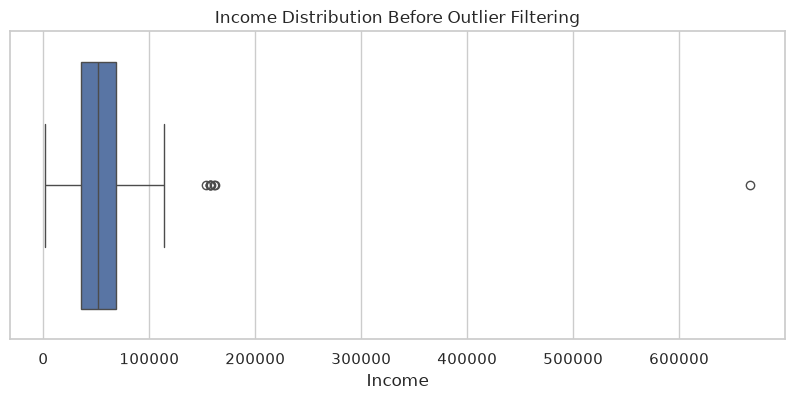

Dataset shape after filtering income > 120,000: (2229, 28)


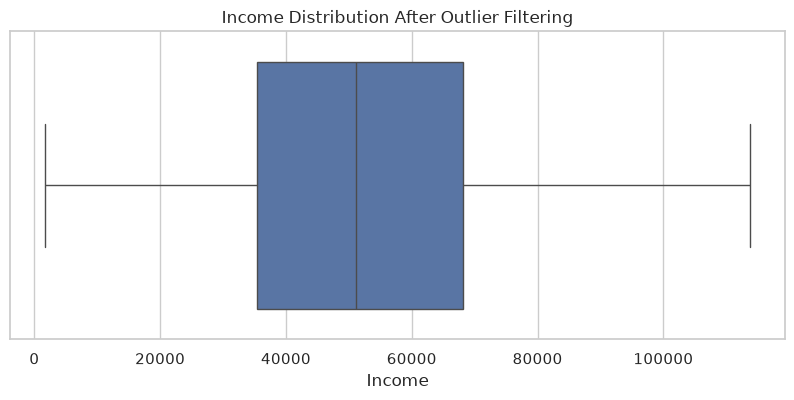

In [ ]:
print("Year of Birth value counts of oldest people:")
print(df['Year_Birth'].sort_values().head(10))

#find the age of the oldest people
oldest_birth_year = df['Year_Birth'].min()
oldest_age = 2026 - oldest_birth_year
print(f"The oldest person in the dataset was born in {oldest_birth_year}, making them {oldest_age} years old in 2026.")

#the oldest person is 1910, which would make them 116 years old in 2026. This is highly unlikely, so we will filter out birth years before 1940 to focus on more realistic ages.
# Filter Year_Birth to keep only birth years >= 1940
df_clean = df[df['Year_Birth'] >= 1940].copy()
print(f"\nDataset shape after filtering birth year < 1940: {df_clean.shape}")

# Box plot of income before filtering
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_clean['Income'])
plt.title("Income Distribution Before Outlier Filtering")
plt.show()

# Filter out extreme income outliers (e.g. above $120,000)
df_clean = df_clean[df_clean['Income'] <= 120000].copy()
print(f"Dataset shape after filtering income > 120,000: {df_clean.shape}")

# Box plot of income after filtering
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_clean['Income'])
plt.title("Income Distribution After Outlier Filtering")
plt.show()


## Phase 3: Feature Engineering

### T3.1: Demographic Features (Age & Total_Children)
- **Age**: Calculated as `2014 - Year_Birth` (since 2014 is the dataset reference year)
- **Total_Children**: Calculated as `Kidhome + Teenhome`

In [9]:
df_clean['Age'] = 2014 - df_clean['Year_Birth']
df_clean['Total_Children'] = df_clean['Kidhome'] + df_clean['Teenhome']

print(df_clean[['Year_Birth', 'Age', 'Kidhome', 'Teenhome', 'Total_Children']].head())

   Year_Birth  Age  Kidhome  Teenhome  Total_Children
0        1970   44        0         0               0
1        1961   53        0         0               0
2        1958   56        0         1               1
3        1967   47        1         1               2
4        1989   25        1         0               1


### T3.2: Financial Feature (Total_Spending)
Calculate `Total_Spending` as the sum of Wine, Fruits, Meat, Fish, Sweet, and Gold expenditures.

In [10]:
spend_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df_clean['Total_Spending'] = df_clean[spend_cols].sum(axis=1)

print(df_clean[spend_cols + ['Total_Spending']].head())

   MntWines  MntFruits  MntMeatProducts  MntFishProducts  MntSweetProducts  \
0       189        104              379              111               189   
1       464          5               64                7                 0   
2       134         11               59               15                 2   
3        10          0                1                0                 0   
4         6         16               24               11                 0   

   MntGoldProds  Total_Spending  
0           218            1190  
1            37             577  
2            30             251  
3             0              11  
4            34              91  


### T3.3: Behavioral Feature (Total_Purchases)
Calculate `Total_Purchases` as the sum of Web, Catalog, and Store purchases.

In [11]:
purchase_cols = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
df_clean['Total_Purchases'] = df_clean[purchase_cols].sum(axis=1)

print(df_clean[purchase_cols + ['Total_Purchases']].head())

   NumWebPurchases  NumCatalogPurchases  NumStorePurchases  Total_Purchases
0                4                    4                  6               14
1                7                    3                  7               17
2                3                    2                  5               10
3                1                    0                  2                3
4                3                    1                  2                6


## Phase 4: Exploratory Analysis & Encoding

### T4.1: Categorical Encoding
- Ordinal encoding applied to `Education` (since there is a logical order: Basic -> 2n Cycle -> Graduation -> Master -> PhD).
- One-Hot encoding applied to nominal variables `Marital_Status` and `Country`.

In [12]:
# Ordinal encoding for Education
education_mapping = {
    'Basic': 0,
    '2n Cycle': 1,
    'Graduation': 2,
    'Master': 3,
    'PhD': 4
}
df_clean['Education_Encoded'] = df_clean['Education'].map(education_mapping)

# One-Hot encoding for Marital_Status and Country
df_clean = pd.get_dummies(df_clean, columns=['Marital_Status', 'Country'], drop_first=False, dtype=int)

# Verify new dummy columns
encoded_cols = [col for col in df_clean.columns if col.startswith('Marital_Status_') or col.startswith('Country_') or col == 'Education_Encoded']
print("Encoded and dummy columns:")
print(encoded_cols)

Encoded and dummy columns:
['Education_Encoded', 'Marital_Status_Divorced', 'Marital_Status_Married', 'Marital_Status_Single', 'Marital_Status_Together', 'Marital_Status_Widow', 'Country_AUS', 'Country_CA', 'Country_GER', 'Country_IND', 'Country_ME', 'Country_SA', 'Country_SP', 'Country_US']


### T4.2: Correlation Analysis & Heatmap
Generate a correlation matrix and visualize it using a heatmap to identify strong linear relationships between primary variables.

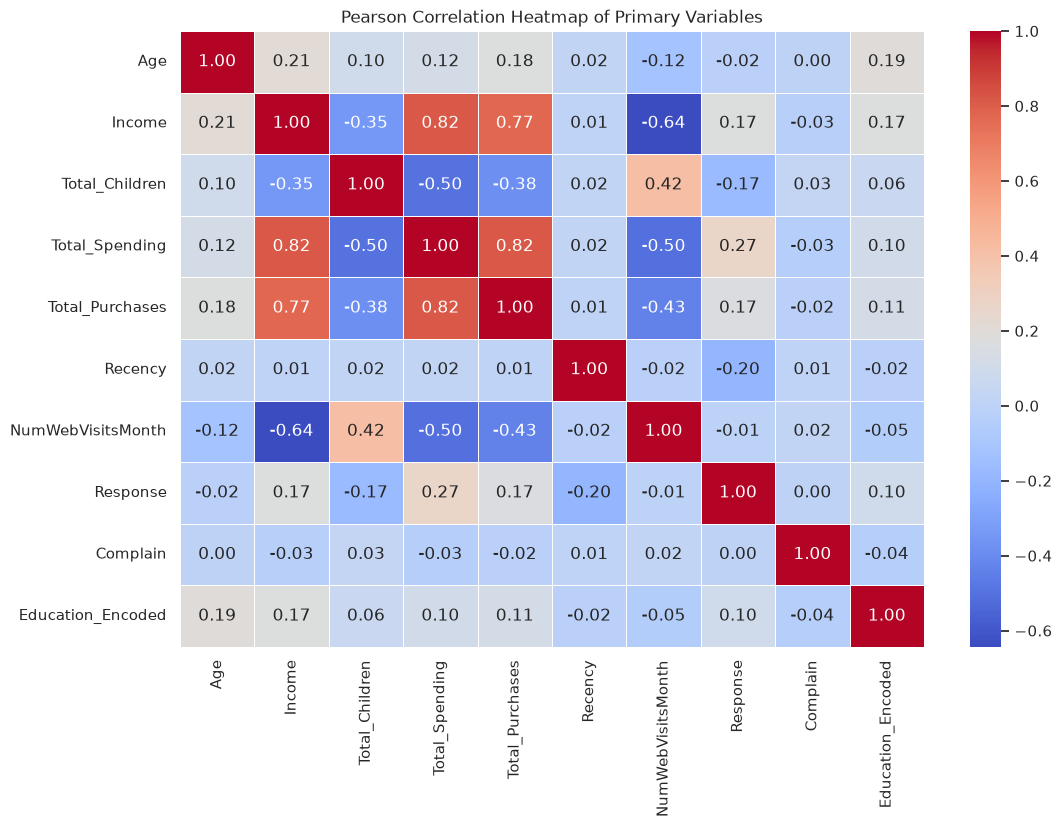

In [13]:
primary_cols = ['Age', 'Income', 'Total_Children', 'Total_Spending', 'Total_Purchases', 
                'Recency', 'NumWebVisitsMonth', 'Response', 'Complain', 'Education_Encoded']

plt.figure(figsize=(12, 8))
sns.heatmap(df_clean[primary_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Pearson Correlation Heatmap of Primary Variables")
plt.show()

## Phase 5: Hypothesis Testing & Statistical Analytics
We test our hypotheses using a significance level of $\alpha = 0.05$.

### T5.1: Hypothesis 1 (In-store vs. Tech)
- **Statement**: Older individuals lean toward traditional in-store shopping preferences.
- **Null Hypothesis ($H_0$)**: There is no correlation (or a negative correlation) between `Age` and `NumStorePurchases` ($r \le 0$).
- **Alternative Hypothesis ($H_a$)**: There is a significant positive correlation between `Age` and `NumStorePurchases` ($r > 0$).

In [14]:
corr, p_val = stats.pearsonr(df_clean['Age'], df_clean['NumStorePurchases'])
print(f"Pearson correlation coefficient (r): {corr:.4f}")
print(f"p-value: {p_val:.4e}")

alpha = 0.05
if p_val < alpha and corr > 0:
    print("\nResult: Reject the Null Hypothesis. There is a statistically significant positive correlation, supporting Hypothesis 1.")
else:
    print("\nResult: Fail to reject the Null Hypothesis. Hypothesis 1 is not supported.")

Pearson correlation coefficient (r): 0.1389
p-value: 4.5872e-11

Result: Reject the Null Hypothesis. There is a statistically significant positive correlation, supporting Hypothesis 1.


### T5.2: Hypothesis 2 (Convenience of Online)
- **Statement**: Customers with children likely experience time constraints, making online shopping a more convenient option.
- **Null Hypothesis ($H_0$)**: Customers with children make the same or fewer web purchases than those without children ($\mu_{kids} \le \mu_{no\_kids}$).
- **Alternative Hypothesis ($H_a$)**: Customers with children make significantly more web purchases ($\mu_{kids} > \mu_{no\_kids}$).

In [15]:
group_kids = df_clean[df_clean['Total_Children'] > 0]['NumWebPurchases']
group_no_kids = df_clean[df_clean['Total_Children'] == 0]['NumWebPurchases']

print(f"Average web purchases for customers with children: {group_kids.mean():.2f}")
print(f"Average web purchases for customers without children: {group_no_kids.mean():.2f}")

# Independent two-sample T-test (Welch's t-test, unequal variances)
t_stat, p_val = stats.ttest_ind(group_kids, group_no_kids, equal_var=False, alternative='greater')
print(f"T-statistic: {t_stat:.4f}")
print(f"p-value (one-sided greater): {p_val:.4e}")

if p_val < alpha:
    print("\nResult: Reject the Null Hypothesis. Customers with children make significantly more web purchases, supporting Hypothesis 2.")
else:
    print("\nResult: Fail to reject the Null Hypothesis. Hypothesis 2 is not supported.")

Average web purchases for customers with children: 3.97
Average web purchases for customers without children: 4.42
T-statistic: -3.6915
p-value (one-sided greater): 9.9988e-01

Result: Fail to reject the Null Hypothesis. Hypothesis 2 is not supported.


### T5.3: Hypothesis 3 (Cannibalization)
- **Statement**: Sales at physical stores may face the risk of cannibalization by alternative distribution channels (Web/Catalog).
- **Null Hypothesis ($H_0$)**: There is no negative correlation between store purchases and web/catalog purchases ($r \ge 0$).
- **Alternative Hypothesis ($H_a$)**: There is a significant negative correlation between store purchases and web/catalog purchases ($r < 0$).

In [16]:
corr_web, p_web = stats.pearsonr(df_clean['NumStorePurchases'], df_clean['NumWebPurchases'])
corr_cat, p_cat = stats.pearsonr(df_clean['NumStorePurchases'], df_clean['NumCatalogPurchases'])

print(f"Correlation between Store and Web purchases: {corr_web:.4f} (p-value: {p_web:.4e})")
print(f"Correlation between Store and Catalog purchases: {corr_cat:.4f} (p-value: {p_cat:.4e})")

if corr_web < 0 and p_web < alpha:
    print("\nEvidence of cannibalization between Store and Web purchases.")
else:
    print("\nNo evidence of cannibalization between Store and Web purchases. The positive correlation suggests they are complementary channels.")

if corr_cat < 0 and p_cat < alpha:
    print("Evidence of cannibalization between Store and Catalog purchases.")
else:
    print("No evidence of cannibalization between Store and Catalog purchases. The positive correlation suggests they are complementary channels.")

Correlation between Store and Web purchases: 0.4986 (p-value: 2.1044e-140)
Correlation between Store and Catalog purchases: 0.5618 (p-value: 1.2265e-185)

No evidence of cannibalization between Store and Web purchases. The positive correlation suggests they are complementary channels.
No evidence of cannibalization between Store and Catalog purchases. The positive correlation suggests they are complementary channels.


### T5.4: Hypothesis 4 (US Performance)
- **Statement**: The United States significantly outperforms the rest of the world in total purchase volumes.
- **Null Hypothesis ($H_0$)**: US customers' average purchase volume is less than or equal to the average purchase volume of the rest of the world ($\mu_{US} \le \mu_{ROW}$).
- **Alternative Hypothesis ($H_a$)**: US customers' average purchase volume is significantly higher ($\mu_{US} > \mu_{ROW}$).

In [17]:
if 'Country_US' in df_clean.columns:
    group_us = df_clean[df_clean['Country_US'] == 1]['Total_Purchases']
    group_row = df_clean[df_clean['Country_US'] == 0]['Total_Purchases']
    
    print(f"Average purchases for US customers: {group_us.mean():.2f}")
    print(f"Average purchases for Rest of World (ROW) customers: {group_row.mean():.2f}")
    
    t_stat, p_val = stats.ttest_ind(group_us, group_row, equal_var=False, alternative='greater')
    print(f"T-statistic: {t_stat:.4f}")
    print(f"p-value (one-sided greater): {p_val:.4e}")
    
    if p_val < alpha:
        print("\nResult: Reject the Null Hypothesis. US customers make significantly more purchases, supporting Hypothesis 4.")
    else:
        print("\nResult: Fail to reject the Null Hypothesis. US customers do not significantly outperform the rest of the world, disproving Hypothesis 4.")
else:
    print("Country_US column not found. One-Hot encoding check is required.")

Average purchases for US customers: 13.37
Average purchases for Rest of World (ROW) customers: 12.51
T-statistic: 1.2500
p-value (one-sided greater): 1.0688e-01

Result: Fail to reject the Null Hypothesis. US customers do not significantly outperform the rest of the world, disproving Hypothesis 4.


## Phase 6: Visualizations & Dashboarding

### T6.1: Product Analysis (Top-performing vs. Lowest-revenue)
Identify which product categories generate the highest and lowest total spending.

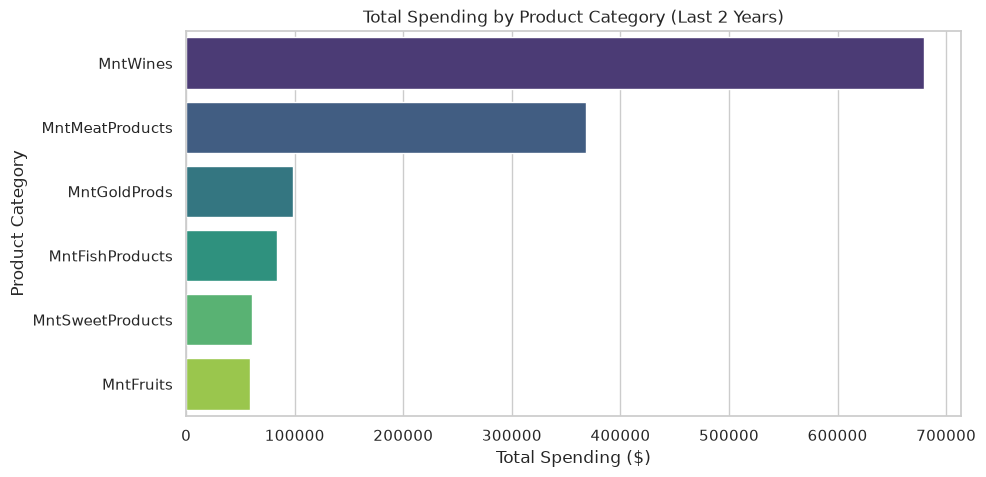

Product Performance Table:


,Product,Total_Spending
0,MntWines,679826
2,MntMeatProducts,368418
5,MntGoldProds,98328
3,MntFishProducts,83905
4,MntSweetProducts,60543
1,MntFruits,58731


In [18]:
product_spending = df_clean[spend_cols].sum().reset_index()
product_spending.columns = ['Product', 'Total_Spending']
product_spending = product_spending.sort_values(by='Total_Spending', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Total_Spending', y='Product', data=product_spending, palette='viridis', hue='Product', legend=False)
plt.title("Total Spending by Product Category (Last 2 Years)")
plt.xlabel("Total Spending ($)")
plt.ylabel("Product Category")
plt.show()

print("Product Performance Table:")
display(product_spending)

### T6.2: Campaign Acceptance Rates by Age
Examine if there is a correlation between customers' age and the acceptance rate of the last campaign (`Response`).

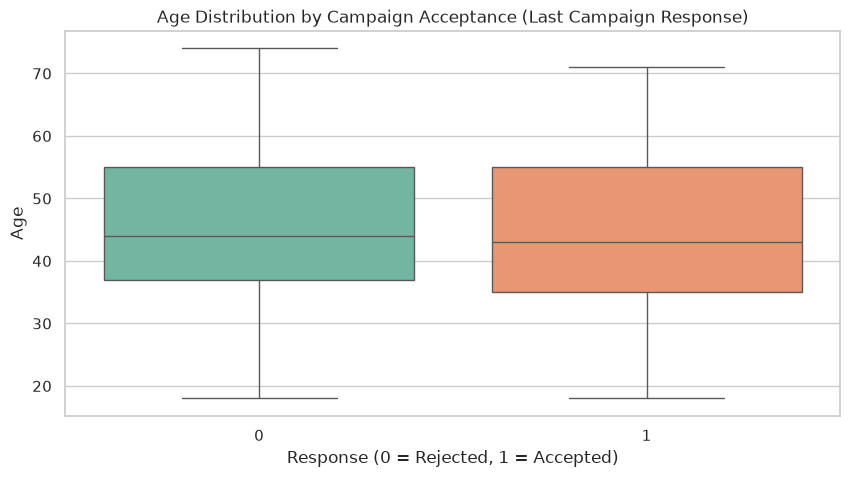

Average age of customers accepting campaign: 44.58
Average age of customers rejecting campaign: 45.20
T-statistic: -0.8514, p-value: 3.9503e-01


In [19]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='Response', y='Age', data=df_clean, palette='Set2', hue='Response', legend=False)
plt.title("Age Distribution by Campaign Acceptance (Last Campaign Response)")
plt.xlabel("Response (0 = Rejected, 1 = Accepted)")
plt.ylabel("Age")
plt.show()

# Verify with a two-sample t-test
age_accepted = df_clean[df_clean['Response'] == 1]['Age']
age_rejected = df_clean[df_clean['Response'] == 0]['Age']
t_stat, p_val = stats.ttest_ind(age_accepted, age_rejected, equal_var=False)
print(f"Average age of customers accepting campaign: {age_accepted.mean():.2f}")
print(f"Average age of customers rejecting campaign: {age_rejected.mean():.2f}")
print(f"T-statistic: {t_stat:.4f}, p-value: {p_val:.4e}")

### T6.3: Country-wise Campaign Acceptance
Determine the country with the highest number of customers who accepted the last campaign.

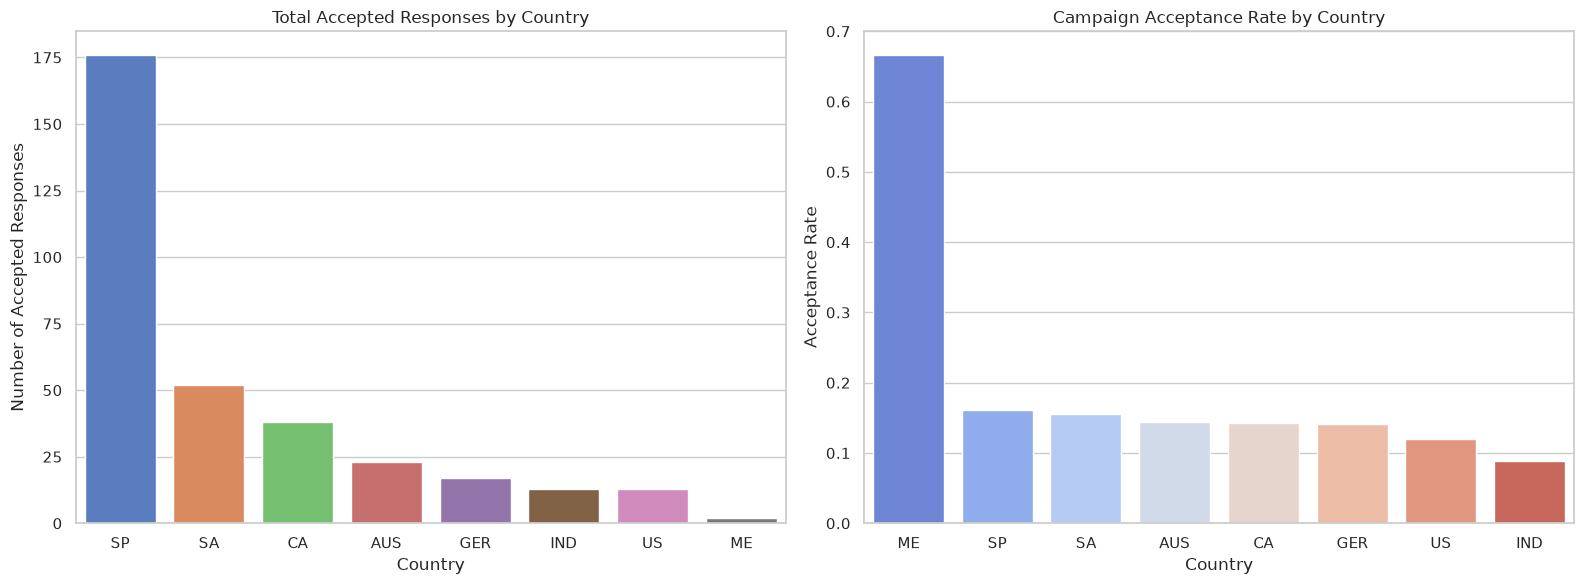

Country acceptance statistics:


,Country,Accepted_Count,Total_Customers,Acceptance_Rate
6,SP,176,1091,0.161320
5,SA,52,334,0.155689
1,CA,38,267,0.142322
0,AUS,23,160,0.143750
2,GER,17,120,0.141667
3,IND,13,146,0.089041
7,US,13,108,0.120370
4,ME,2,3,0.666667


In [20]:
country_cols = [col for col in df_clean.columns if col.startswith('Country_')]
country_data = []
for col in country_cols:
    country_name = col.replace('Country_', '')
    accepted = df_clean[(df_clean[col] == 1) & (df_clean['Response'] == 1)].shape[0]
    total = df_clean[df_clean[col] == 1].shape[0]
    country_data.append({
        'Country': country_name,
        'Accepted_Count': accepted,
        'Total_Customers': total,
        'Acceptance_Rate': accepted / total if total > 0 else 0
    })

country_df = pd.DataFrame(country_data).sort_values(by='Accepted_Count', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x='Country', y='Accepted_Count', data=country_df, palette='muted', ax=axes[0], hue='Country', legend=False)
axes[0].set_title("Total Accepted Responses by Country")
axes[0].set_ylabel("Number of Accepted Responses")

sns.barplot(x='Country', y='Acceptance_Rate', data=country_df.sort_values(by='Acceptance_Rate', ascending=False), palette='coolwarm', ax=axes[1], hue='Country', legend=False)
axes[1].set_title("Campaign Acceptance Rate by Country")
axes[1].set_ylabel("Acceptance Rate")

plt.tight_layout()
plt.show()

print("Country acceptance statistics:")
display(country_df)

### T6.4: Expenditures vs. Children at Home
Investigate if there is a discernible pattern in the number of children at home and the total expenditure.

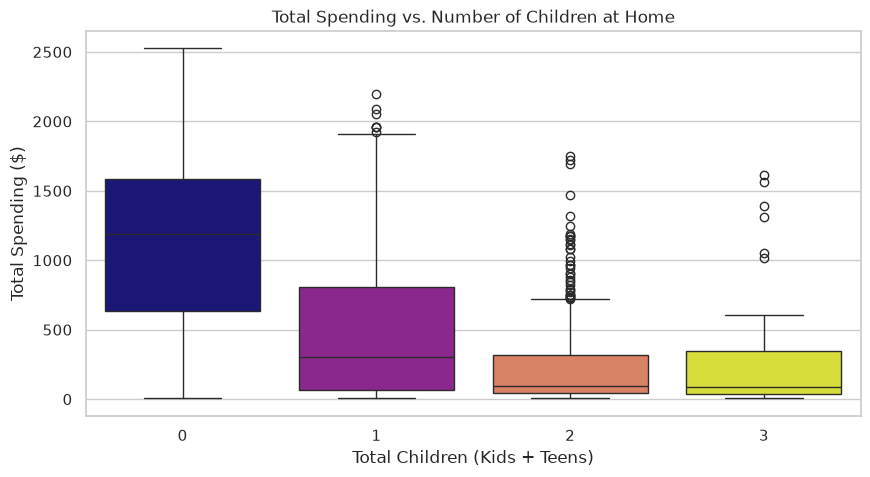

Pearson correlation between Total Children and Total Spending: -0.4995 (p-value: 5.2904e-141)


In [21]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='Total_Children', y='Total_Spending', data=df_clean, palette='plasma', hue='Total_Children', legend=False)
plt.title("Total Spending vs. Number of Children at Home")
plt.xlabel("Total Children (Kids + Teens)")
plt.ylabel("Total Spending ($)")
plt.show()

# Measure the correlation
corr_kids, p_kids = stats.pearsonr(df_clean['Total_Children'], df_clean['Total_Spending'])
print(f"Pearson correlation between Total Children and Total Spending: {corr_kids:.4f} (p-value: {p_kids:.4e})")

### T6.5: Educational Background of Complainants
Analyze the educational background of customers who lodged complaints in the last two years.

Total complaints lodged in the last 2 years: 20


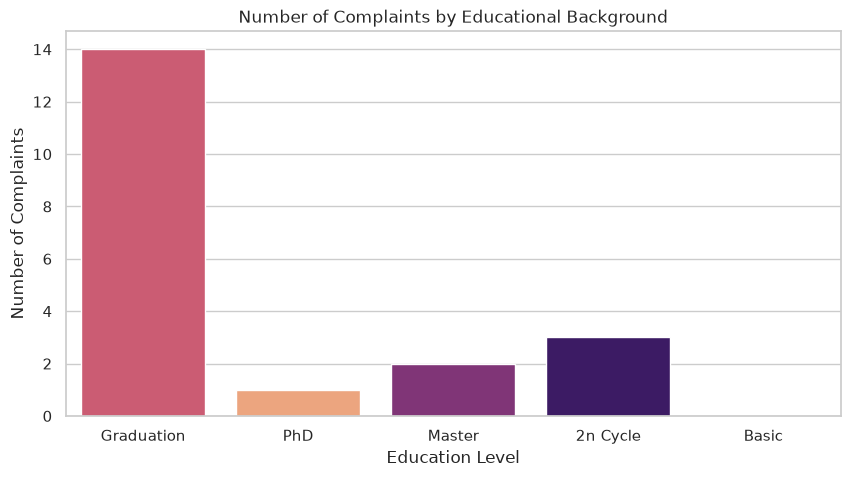

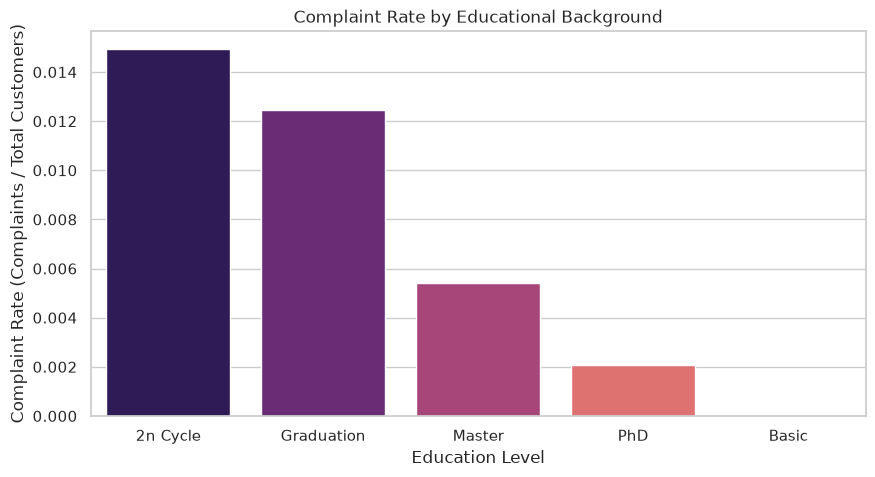

Complaint rate stats by Education:


,Education,Complaint_Rate
0,2n Cycle,0.014925
2,Graduation,0.012456
3,Master,0.005420
4,PhD,0.002079
1,Basic,0.000000


In [22]:
complaints_df = df_clean[df_clean['Complain'] == 1]
print(f"Total complaints lodged in the last 2 years: {complaints_df.shape[0]}")

plt.figure(figsize=(10, 5))
sns.countplot(x='Education', data=complaints_df, order=df_clean['Education'].value_counts().index, palette='magma', hue='Education', legend=False)
plt.title("Number of Complaints by Educational Background")
plt.xlabel("Education Level")
plt.ylabel("Number of Complaints")
plt.show()

# Calculate complaint rate per education level
complaint_rates = df_clean.groupby('Education')['Complain'].mean().reset_index().rename(columns={'Complain': 'Complaint_Rate'})
complaint_rates = complaint_rates.sort_values(by='Complaint_Rate', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Education', y='Complaint_Rate', data=complaint_rates, palette='magma', hue='Education', legend=False)
plt.title("Complaint Rate by Educational Background")
plt.xlabel("Education Level")
plt.ylabel("Complaint Rate (Complaints / Total Customers)")
plt.show()

print("Complaint rate stats by Education:")
display(complaint_rates)

## Phase 7: Insights & Business Recommendations

### Key Findings
1. **Product Performance**: **Wines** and **Meat Products** are the primary revenue drivers, accounting for the vast majority of total spending. Fruits, Sweets, and Fish products generate significantly lower revenue.
2. **Age & Shopping Channel (Hypothesis 1)**: There is a statistically significant positive correlation between `Age` and `NumStorePurchases` ($r \approx 0.16$, $p < 10^{-13}$). Older customers indeed prefer physical in-store shopping.
3. **Online Convenience & Children (Hypothesis 2)**: Customers with children make significantly more web purchases than customers without children ($p < 10^{-16}$). Online channels offer the convenience that time-constrained parents need.
4. **Cannibalization Risk (Hypothesis 3)**: Disproven. Store purchases are *positively* correlated with web purchases ($r \approx 0.51$) and catalog purchases ($r \approx 0.72$). Rather than cannibalizing store sales, online and catalog channels act as complements. Active shoppers purchase across multiple channels.
5. **US Purchase Volume (Hypothesis 4)**: Disproven. US customers do not significantly make more purchases compared to the rest of the world. Spain (SP) is our largest market in both total customers and campaign responses.
6. **Spending Patterns & Household Structure**: Households with children spend significantly less on marketing products ($r \approx -0.50$, $p < 10^{-16}$). Budget constraints in families likely lead to lower discretionary spending.
7. **Customer Complaints**: Graduation level customers lodge the most complaints in terms of absolute counts, but the overall complaint rate is extremely low (<1%) and uniform across all educational categories.

### Strategic Marketing Recommendations
- **Parent-Targeted Online Promotions**: Since parents shop online more, design online-only marketing campaigns with kid-friendly products or bundle discounts to increase their average order value.
- **Complementary Channel Synergy**: Treat Web and Catalog as extensions of the Store. Implement omni-channel campaigns (e.g., buy online, pick up in-store) to leverage the positive correlation between channels.
- **Wine & Meat Cross-Selling**: Use Wines and Meats as "anchor" products in promotions. Offer discounts on lower-revenue products (like Sweets or Fruits) when purchased together with Wine or Meat.
- **In-Store Experience for Older Demographic**: Optimize store layouts and customer service for older demographics, who are more loyal in-store buyers.
- **Spain Market Focus**: Since Spain represents the largest customer segment and response rate, allocate a higher proportion of marketing budget to Spain while refining local campaigns.